# All-Time High — a quantitative teardown 🔬
### Conditional forward returns · Hansen-Hodrick lags · non-overlapping cross-check · the rule as a portfolio

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two things
make this study harder than it looks: forward returns at every session **overlap** almost
perfectly, and every tape in the sample is a **survivor**. Both are handled explicitly below
— one with statistics, the other with a declaration, because it cannot be handled with
statistics.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance, pinned as-of the
> date in [`docs/results.md`](../docs/results.md); literature map in
> [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from ath_buy import data, strategy as st

px = data.load_prices()
cash = px[data.CASH].dropna()
spy = px["SPY"].dropna()
print(f"as-of {data.AS_OF}  |  SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} sessions)")
print(f"share of SPY sessions closing at a record high: "
      f"{st.share_of_days_at_high(spy):.1%}")
print(f"today's distance from the peak: {st.drawdown(spy).iloc[-1]:+.2%}")

as-of 2026-06-30  |  SPY 1993-01-29 -> 2026-06-30 (8,411 sessions)
share of SPY sessions closing at a record high: 10.5%
today's distance from the peak: -1.43%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Money invested on a record-high close earned **+12.4%** over the next twelve months against **+10.2%** from every other day — a gap of **+2.3%** (HAC *t* = +0.17 at the horizon lag; the non-overlapping cross-check gives -0.6%). Record highs are also not rare: **11%** of SPY's sessions closed at one. The direction is the finding — it is not negative — and every tape here is a survivor, which flatters it. |
| **Tradability** | Mirage | Waiting for a **5%** dip and sitting in bills otherwise was invested only 41% of the time and gave up **-5.08%/yr** of compounding on SPY (excess-Sharpe gap -0.22, *t* = -2.54); it won on excess Sharpe on **0 of 6** tapes. The drawdown it buys back is real — the return it gives up is larger. |

> 💡 **In plain words.** The data does not support "records are bad"; it weakly
> supports "records are fine, slightly better than average". The dip rule loses because being
> out of the market is expensive, not because the timing signal is perverse.

## 1 · The claim, steelmanned

- **H₁.** E[r(t → t+h) | close at a record] < E[r(t → t+h) | otherwise], for h ∈ {21, 63, 252}.
- **H₂ (the practical form).** A rule that holds the asset only below its peak earns a higher
  *excess-of-cash Sharpe* than buy-and-hold, net of switching costs.
- **H₃ (the fallback).** Even if H₁ fails on means, records precede *worse tails* — a lower
  win rate or a deeper worst case.

## 2 · So what? — the quantitative stakes

Being out of the market has a price and it is not small: the cash-versus-equity gap over this
sample runs several percent a year. A timing rule must therefore be *right often enough to pay
for its own absence*, which is a far higher bar than "sometimes avoids a crash".

## 3 · How we'd know — the protocol

1. **Total-return peaks.** A price-index record and a wealth-index record are different sets
   of days; the folklore is about money, so the running maximum is computed on total return.
2. **Horizon-lag HAC.** Overlapping windows share all but one observation
   (`conditional_stats` sets `lags = horizon`).
3. **A non-overlapping cross-check** that keeps one observation per horizon and discards the
   rest — the sample size that a twelve-month claim actually has.
4. **The counterfactual as buckets**, not as an average: at the high, 2%, 5%, 10%, 20% below.
5. **The rule as a portfolio**, with one day of lag and costs on every switch.
6. **A synthetic control** on a planted trend and on a random walk.

## 4 · The teardown

### 4.1 Every tape, every horizon

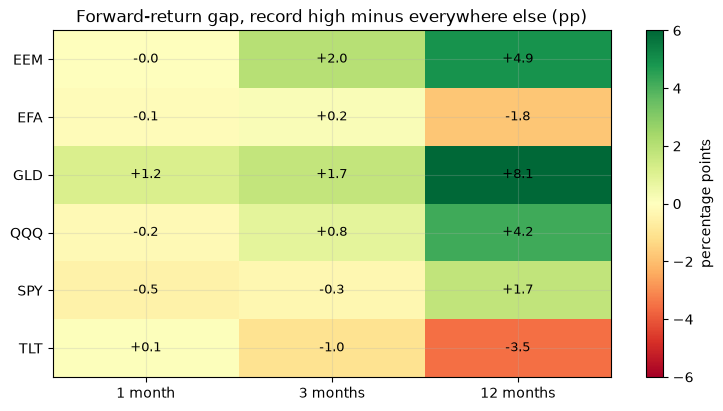

,ticker,horizon,gap,t,n_high
0,SPY,1 month,-0.0051,-1.4881,885
1,SPY,3 months,-0.0028,-0.3126,867
2,SPY,12 months,0.0175,0.4756,826
3,QQQ,1 month,-0.0021,-0.2764,467
4,QQQ,3 months,0.0080,0.3867,450
5,QQQ,12 months,0.0419,0.6516,419
6,EFA,1 month,-0.0011,-0.2518,351
7,EFA,3 months,0.0017,0.1795,351
8,EFA,12 months,-0.0179,-0.3335,311
9,EEM,1 month,-0.0004,-0.0579,298


In [3]:
rows = []
for tk in data.RISKY:
    s = px[tk].dropna()
    t = st.forward_table(s)
    for hz, r in t.iterrows():
        rows.append({"ticker": tk, "horizon": st.HORIZON_LABEL[hz], "gap": r["diff"],
                     "t": r["t_diff"], "n_high": int(r["n_state"])})
grid = pd.DataFrame(rows)
pv = grid.pivot(index="ticker", columns="horizon", values="gap")[
    ["1 month", "3 months", "12 months"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(pv.values * 100, cmap="RdYlGn", vmin=-6, vmax=6, aspect="auto")
ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns)
ax.set_yticks(range(pv.shape[0])); ax.set_yticklabels(pv.index)
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        ax.text(j, i, f"{pv.values[i, j] * 100:+.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Forward-return gap, record high minus everywhere else (pp)")
fig.colorbar(im, ax=ax, label="percentage points")
plt.show()
grid.round(4)

### 4.2 What the overlap is doing to the standard errors

In [4]:
from quantlab.analytics import mean_tstat_hac
f = st.forward_return(spy, 252).dropna()
m = st.at_high(spy).reindex(f.index).fillna(False)
comp = pd.DataFrame({
    "lags = 0 (wrong)": [mean_tstat_hac(f[m], lags=0)["tstat"]],
    "lags = 21": [mean_tstat_hac(f[m], lags=21)["tstat"]],
    "lags = 252 (Hansen-Hodrick)": [mean_tstat_hac(f[m], lags=252)["tstat"]],
}, index=["t on the mean 12m return after a record"])
non = st.nonoverlap_stats(spy, 252)
print(f"non-overlapping: {non['n_state']} record-year observations vs {non['n_other']} others, "
      f"gap {non['diff']:+.2%}, t {non['t_diff']:+.2f}")
comp.round(2)

non-overlapping: 6 record-year observations vs 27 others, gap -0.63%, t -0.12


,lags = 0 (wrong),lags = 21,lags = 252 (Hansen-Hodrick)
t on the mean 12m return after a record,29.9700,7.3700,5.2900


> 💡 **In plain words.** The same data can produce a *t* of 8 or a *t* of 1
> depending only on whether you admit that overlapping years are not independent. This is the
> most common way a long-horizon claim gets published.

### 4.3 The distribution, not the mean

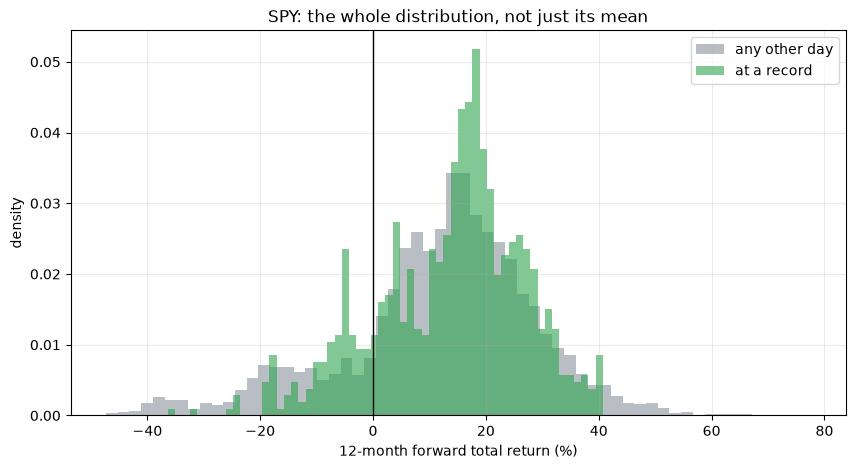

,at a record,any other day
mean,0.1364,0.1189
sd,0.1309,0.1712
5th pct,-0.0973,-0.2057
win rate,0.8390,0.8140


In [5]:
f12 = st.forward_return(spy, 252).dropna()
m = st.at_high(spy).reindex(f12.index).fillna(False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(f12[~m] * 100, bins=60, alpha=0.6, density=True, color="#8b949e", label="any other day")
ax.hist(f12[m] * 100, bins=60, alpha=0.6, density=True, color="#2ea44f", label="at a record")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("12-month forward total return (%)"); ax.set_ylabel("density")
ax.set_title("SPY: the whole distribution, not just its mean")
ax.legend()
plt.show()
pd.DataFrame({
    "at a record": [f12[m].mean(), f12[m].std(), f12[m].quantile(0.05), (f12[m] > 0).mean()],
    "any other day": [f12[~m].mean(), f12[~m].std(), f12[~m].quantile(0.05), (f12[~m] > 0).mean()],
}, index=["mean", "sd", "5th pct", "win rate"]).round(4)

### 4.4 The rule, priced properly

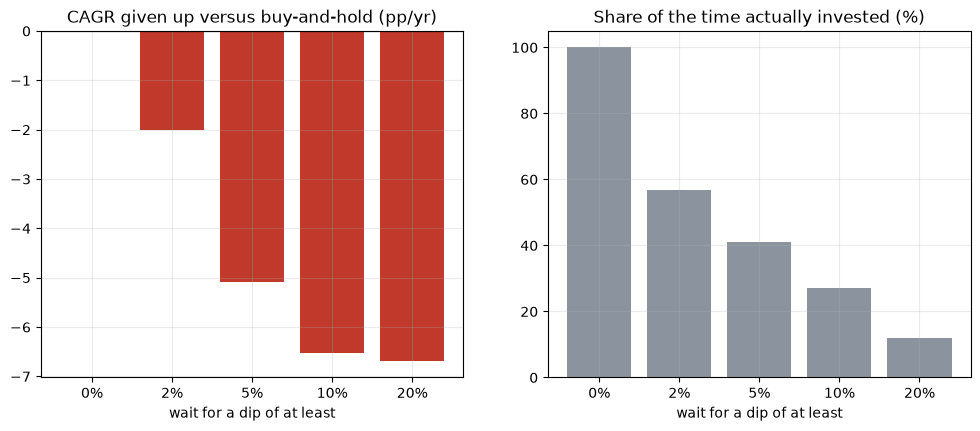

,time_invested,cagr,cagr_gap,sharpe,sharpe_gap,max_dd,t_gap,switches_per_year
dip,,,,,,,,
0.0000,0.9998,0.1069,-0.0000,0.5423,-0.0001,-0.5519,-1.0003,0.0525
0.0200,0.5675,0.0869,-0.0200,0.4663,-0.0761,-0.5389,-1.3284,13.5918
0.0500,0.4098,0.0561,-0.0508,0.3206,-0.2218,-0.5279,-2.5393,6.9271
0.1000,0.2716,0.0418,-0.0652,0.2497,-0.2927,-0.4920,-2.6081,3.6735
0.2000,0.1193,0.0401,-0.0669,0.2638,-0.2786,-0.4341,-2.2799,1.9942


In [6]:
c = cash.reindex(spy.index).ffill().dropna()
s = spy.reindex(c.index)
sw = st.dip_sweep(s, c, dips=(0.0, 0.02, 0.05, 0.10, 0.20), cost_bps=2.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([f"{d:.0%}" for d in sw.index], sw["cagr_gap"] * 100, color="#c0392b")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("CAGR given up versus buy-and-hold (pp/yr)")
axes[1].bar([f"{d:.0%}" for d in sw.index], sw["time_invested"] * 100, color="#8b949e")
axes[1].set_title("Share of the time actually invested (%)")
for a in axes:
    a.set_xlabel("wait for a dip of at least")
plt.show()
sw.round(4)

### 4.5 Costs are not the binding constraint — absence is

In [7]:
rows = []
for cb in (0.0, 2.0, 5.0, 20.0):
    r = st.race(s, c, 0.05, cb)
    rows.append({"cost_bps": cb, "cagr_gap": r["cagr_gap"], "sharpe_gap": r["sharpe_gap"],
                 "switches_per_year": r["switches_per_year"]})
pd.DataFrame(rows).set_index("cost_bps").round(4)

,cagr_gap,sharpe_gap,switches_per_year
cost_bps,,,
0.0000,-0.0493,-0.2139,6.9271
2.0000,-0.0508,-0.2218,6.9271
5.0000,-0.0530,-0.2336,6.9271
20.0000,-0.0639,-0.2929,6.9271


> 💡 **In plain words.** Take the trading costs to zero and the rule still
> loses. What it pays for is the *time out of the market*, and no broker can discount that.

## 5 · The verdict

The decisive numbers: the pooled 12-month gap and its honest *t*, the non-overlapping
cross-check, and the rule's CAGR gap.

In [8]:
pool = []
for tk in data.RISKY:
    s_ = px[tk].dropna()
    t = st.forward_table(s_).loc[252]
    n = st.nonoverlap_stats(s_, 252)
    c_ = cash.reindex(s_.index).ffill().dropna()
    r = st.race(s_.reindex(c_.index), c_, 0.05, 2.0)
    pool.append({"ticker": tk, "12m gap": t["diff"], "HAC t": t["t_diff"],
                 "non-overlap gap": n["diff"], "dip-rule CAGR gap": r["cagr_gap"],
                 "dip-rule Sharpe gap": r["sharpe_gap"]})
summary = pd.DataFrame(pool).set_index("ticker")
print(summary.round(4).to_string())
print(f"\npooled 12m gap {summary['12m gap'].mean():+.2%} | "
      f"mean HAC t {summary['HAC t'].mean():+.2f} | "
      f"positive on {(summary['12m gap'] > 0).sum()}/6 tapes | "
      f"dip rule wins Sharpe on {(summary['dip-rule Sharpe gap'] > 0).sum()}/6")

        12m gap   HAC t  non-overlap gap  dip-rule CAGR gap  dip-rule Sharpe gap
ticker                                                                          
SPY      0.0175  0.4756          -0.0063            -0.0508              -0.2218
QQQ      0.0419  0.6516              NaN            -0.0692              -0.2327
EFA     -0.0179 -0.3335              NaN            -0.0007              -0.0014
EEM      0.0490  0.5375              NaN            -0.0136              -0.0484
TLT     -0.0355 -1.3796              NaN            -0.0065              -0.0406
GLD      0.0809  1.0712              NaN            -0.0580              -0.2919

pooled 12m gap +2.26% | mean HAC t +0.17 | positive on 4/6 tapes | dip rule wins Sharpe on 0/6


## 6 · Could you trade it?

There is nothing to trade on the long side: "keep owning it" is not a trade. The tradable
question is whether the *avoidance* rule pays, and it does not — before costs, after costs, or
at any patience threshold tested.

## 7 · Going further

- **A non-survivor tape.** The Nikkei 1990-2024, or the FTSE 100 in real terms, is the
  experiment that would falsify the comfortable reading of this study.
- **Conditioning on valuation** (CAPE, excess CAPE yield) rather than on price level — the
  version of the claim that has actual academic support (studies 118, 120 on this desk).
- **Path dependence:** records reached after a long grind versus records reached in a vertical
  melt-up may behave differently; a hazard model on time-since-last-record would test it.
- **Options overlay** at records instead of cash: same fear, much smaller opportunity cost.